## Project 2

#### Analysis of a data set to answer below questions about the data. 
##### A. In Baltimore city, the police department has more employees compared to any other department.
 
##### B. Inspector general department has a high average salary rate when compared to any other department.

In [1]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Loading the dataset
df = pd.read_csv('https://raw.githubusercontent.com/JvcChandu/Data_601/main/Baltimore_City_Employee_Salaries.csv')
df

,lastName,middleInitial,firstName,jobClass,agencyName,agencyID,annualSalary,grossPay,hireDate,fiscalYear,ObjectId
0,Aaron,D,Kareem,UTILITIES INST REPAIR II,Public Works - Water & Waste Water,A50,34115.0,44557.99,2018-08-27,FY2021,1
1,Aaron,R,Lynda,ELECTION JUDGES REGULAR,D01,D01,0.0,185.00,2020-12-08,FY2021,2
2,Aaron,G,Patricia,FACILITIES/OFFICE SERVICES II,Mayor's Office of Employment Development,A03,63457.0,29461.96,1979-10-24,FY2021,3
3,Abadir,O,Adam,OPERATIONS OFFICER II,Health Department,A65,74299.0,85450.35,2016-12-12,FY2021,4
4,Abaku,O,Aigbolosimuan,POLICE OFFICER EID,Police Department,A99,68226.0,102775.97,2018-04-17,FY2021,5
...,...,...,...,...,...,...,...,...,...,...,...
154182,NaN,9,BPD,BPD,Police Department,A99,65499.0,64127.83,1970-01-01,FY2011,154183
154183,NaN,0,BPD,BPD,Police Department,A99,63384.0,66187.45,1970-01-01,FY2011,154184
154184,NaN,1,BPD,BPD,Police Department,A99,61102.0,71989.51,1970-01-01,FY2011,154185
154185,NaN,2,BPD,BPD,Police Department,A99,59958.0,53235.59,1970-01-01,FY2011,154186


In [3]:
#Total rows and columns in data set.
df.shape

(154187, 11)

#### Looking for NULL values in columns and replacing them with appropriate Values

In [4]:
#Shows the total number of null values in each columns
df.isnull().sum()

lastName           410
middleInitial    32992
firstName            0
jobClass           184
agencyName           0
agencyID             0
annualSalary         0
grossPay             0
hireDate             2
fiscalYear           0
ObjectId             0
dtype: int64

In [5]:
#Null values in the lastName column was replaced by Unknown.
df.lastName.fillna('Unknown', inplace=True)
df.lastName

0           Aaron
1           Aaron
2           Aaron
3          Abadir
4           Abaku
           ...   
154182    Unknown
154183    Unknown
154184    Unknown
154185    Unknown
154186    Unknown
Name: lastName, Length: 154187, dtype: object

In [6]:
# Checking...
df['lastName'].isna().values.any()

False

In [7]:
#Null values in the middleInitial column was replaced by first letter in their first name.
mid_int = df['firstName'].astype(str).str[0]
df.middleInitial.fillna(mid_int, inplace=True)
df.middleInitial

0         D
1         R
2         G
3         O
4         O
         ..
154182    9
154183    0
154184    1
154185    2
154186    3
Name: middleInitial, Length: 154187, dtype: object

In [8]:
# Checking...
df['middleInitial'].isna().values.any()

False

In [9]:
# Null values in the jobClass column was replaced by agencyName column values.
df.jobClass.fillna(df.agencyName, inplace = True)
df.jobClass

0              UTILITIES INST REPAIR II
1               ELECTION JUDGES REGULAR
2         FACILITIES/OFFICE SERVICES II
3                 OPERATIONS OFFICER II
4                    POLICE OFFICER EID
                      ...              
154182                              BPD
154183                              BPD
154184                              BPD
154185                              BPD
154186                              BPD
Name: jobClass, Length: 154187, dtype: object

In [10]:
# Checking...
df['jobClass'].isna().values.any()

False

In [11]:
# Finding the location of null values in hireDate column
df.loc[df.hireDate.isna()]

,lastName,middleInitial,firstName,jobClass,agencyName,agencyID,annualSalary,grossPay,hireDate,fiscalYear,ObjectId
5126,Greer,D,De’Ondre,SEASONAL MAINT AIDE,General Services,A85,14.0,2055.23,NaN,FY2021,5127
6097,Horsey,C,Rashad,POLICE OFFICER TRAINEE,Police Department,A99,55117.0,20857.58,NaN,FY2021,6098


In [12]:
#Null values in the hireDate column was replaced by '2000-05-13'
df.hireDate.fillna('2000-05-13', inplace = True)
df.hireDate

0         2018-08-27
1         2020-12-08
2         1979-10-24
3         2016-12-12
4         2018-04-17
             ...    
154182    1970-01-01
154183    1970-01-01
154184    1970-01-01
154185    1970-01-01
154186    1970-01-01
Name: hireDate, Length: 154187, dtype: object

In [13]:
# Checking...
df['hireDate'].isna().values.any()

False

#### Calculating Total No of employees in each department.

In [14]:
df1 = df.groupby(['agencyName']).agg(count = ('firstName','count'))
df1.reset_index(inplace=True)
df1

,agencyName,count
0,BCIT 311 Call Center,54
1,BPD 1,16
2,Baltimore City Office of Information and Techn...,1754
3,Cable & Communications,48
4,City Council,985
...,...,...
66,Una 01 (001),1
67,W07 - OED - Youth Works,138
68,Wage Commissioner,3
69,War Memorial Commission,8


In [15]:
# Increasing the figure size for clear visualization
plt.rcParams["figure.figsize"]=(20,10)

/opt/anaconda3/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/opt/anaconda3/lib/python3.7/site-packages/matplotlib/axes/_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/opt/anaconda3/lib/python3.7/site-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


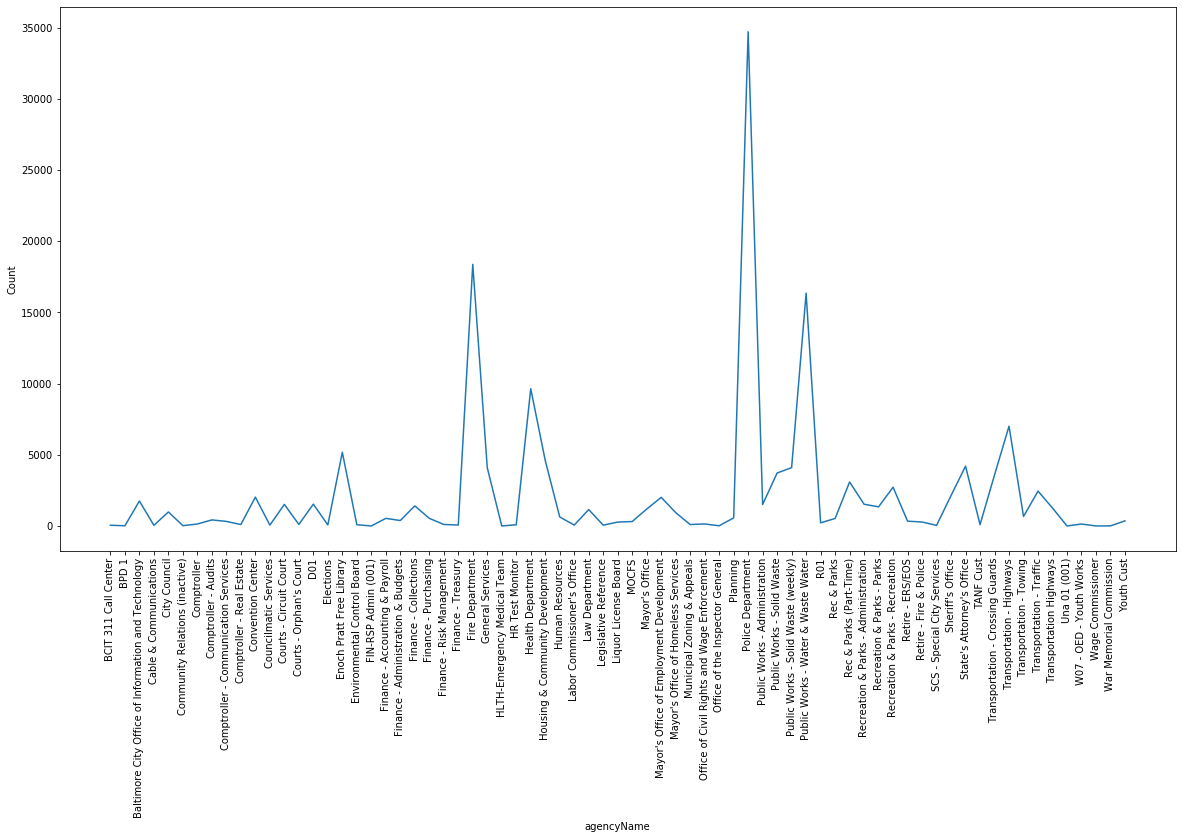

In [16]:
#plotting a line graph
plt.xlabel('agencyName')
plt.xticks(rotation=90)
plt.ylabel('Count')
plt.plot(df1['agencyName'],df1['count'])

### A. In Baltimore city, the police department has more employees compared to any other department. 

#### From the above graph we can clearly say that the above statement is true.

In [17]:
#Average of annualSalary in every department is calculated and sorted them.
df2 = df.groupby(['agencyName']).agg(MEAN = ('annualSalary','mean'))
df2.reset_index(inplace=True)
df2

,agencyName,MEAN
0,BCIT 311 Call Center,48277.500000
1,BPD 1,88454.000000
2,Baltimore City Office of Information and Techn...,56147.002452
3,Cable & Communications,66550.812500
4,City Council,54283.222294
...,...,...
66,Una 01 (001),0.000000
67,W07 - OED - Youth Works,21765.891304
68,Wage Commissioner,57640.333333
69,War Memorial Commission,41461.250000


In [18]:
# Increasing the figure size for clear visulaization
plt.rcParams["figure.figsize"]=(20,10)

/opt/anaconda3/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/opt/anaconda3/lib/python3.7/site-packages/matplotlib/axes/_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/opt/anaconda3/lib/python3.7/site-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


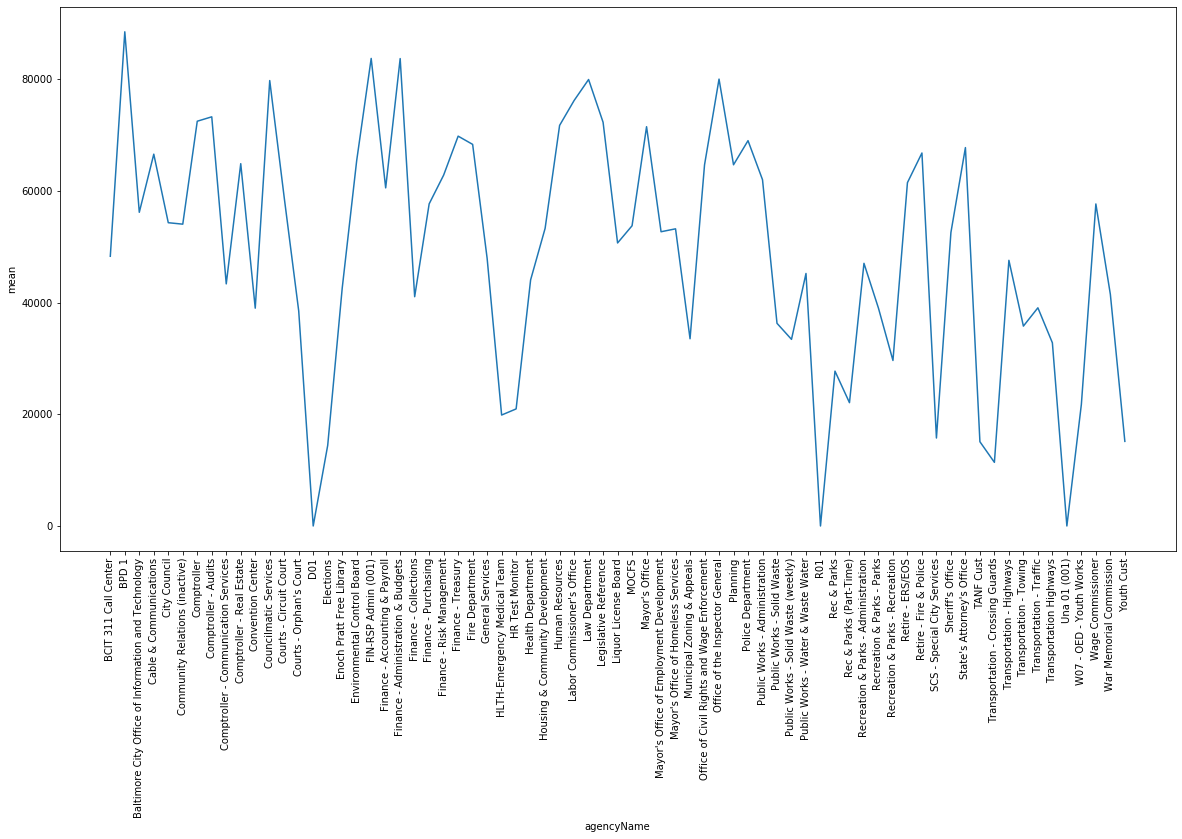

In [19]:
#plotting a line graph 
plt.xlabel('agencyName')
plt.xticks(rotation=90)
plt.ylabel('mean')
plt.plot(df2['agencyName'],df2['MEAN'])

### B. Inspector general department has a high average salary rate when compared to any other department.

#### By seeing the above graph we can clearly say that the above statement is 'False'.